## Packages

In [1]:
import spatialdata as spd
import matplotlib.pyplot as plt
import anndata as ad
import squidpy as sq
import numpy as np
import spatialdata as spd

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [3]:
from pathlib import Path


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



# Data

In [4]:
proj_folder   = Path("/coh_labs/yunroseli/Jona/CAR-T/") # Most up to date files
zarr_file     = proj_folder / "data/zarr/CellCharterClusters_c2l_annotated"

# code_folder   = Path("/home/janzules/spatial/CAR-T/code")
# hallmark_file = code_folder / "references/Mouse_Hallmark.gmt"

## Loading Data

In [5]:
#Reading in files

sdata = spd.read_zarr(zarr_file)
adata = sdata.tables['segmentation_counts']

In [ ]:
adata.obs['c2l_winner']

c2l_winner
Unknown              239346
Cancer_cell           76636
N2_like_Neu           22672
M2_like_Mac           16406
Erythrocyte           13881
Fibroblast            13700
Classical_Mono        10451
N1_like_Neu           10168
Endothelial            6076
NK                     4505
CD8_T                  3421
M1_like_Mac            3228
B                      2379
cDC                    1664
CD4_T                   380
Intermediate_Mac        296
Nonclassical_Mono       225
pDC                     171
NKT                     165
Treg                     89
Name: count, dtype: int64

In [24]:
# Dropping unknown cells
adata = adata[
    (adata.obs['c2l_winner'] != 'Unknown') & 
    (adata.obs['c2l_winner'] != 'Erythrocyte')
].copy()


# Visualizing

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ----------------------------
# User settings
# ----------------------------
cell_col = "c2l_winner"
sample_col = "mouse"       # most specific tissue/sample label
condition_col = "treatment"  # or "condition", depending on your obs columns

# ----------------------------
# Basic checks
# ----------------------------
required_cols = [cell_col, sample_col, condition_col]
missing = [c for c in required_cols if c not in adata.obs.columns]

if missing:
    raise ValueError(f"Missing columns in adata.obs: {missing}")

obs = adata.obs[required_cols].copy()
obs = obs.dropna(subset=[cell_col, sample_col, condition_col])

obs[cell_col] = obs[cell_col].astype(str)
obs[sample_col] = obs[sample_col].astype(str)
obs[condition_col] = obs[condition_col].astype(str)

# ----------------------------
# Counts and fractions per sample
# ----------------------------
sample_counts = pd.crosstab(obs[sample_col], obs[cell_col])
sample_fractions = sample_counts.div(sample_counts.sum(axis=1), axis=0)

sample_metadata = (
    obs[[sample_col, condition_col]]
    .drop_duplicates()
    .set_index(sample_col)
)

sample_fractions = sample_fractions.join(sample_metadata)

print("Sample-level count table:")
display(sample_counts.head())

print("Sample-level fraction table:")
display(sample_fractions.head())

print("\nNumber of cells per sample:")
display(sample_counts.sum(axis=1).sort_values(ascending=False))

Sample-level count table:


c2l_winner,B,CD4_T,CD8_T,Cancer_cell,Classical_Mono,Endothelial,Fibroblast,Intermediate_Mac,M1_like_Mac,M2_like_Mac,N1_like_Neu,N2_like_Neu,NK,NKT,Nonclassical_Mono,Treg,cDC,pDC
mouse,,,,,,,,,,,,,,,,,,
CyPSCA_1_1,209,121,1068,5976,2151,122,116,16,645,138,1053,112,892,53,27,22,78,44
CyPSCA_1_2,131,34,144,3852,2308,224,84,10,106,179,1213,378,213,10,13,7,49,7
CyPSCA_2_4,52,7,997,1936,933,209,59,7,450,198,643,39,317,4,9,0,30,0
CyT72_1_2,21,1,21,19,95,201,598,7,29,898,296,22,55,1,8,4,121,2
CyT72_1_4,136,4,56,47,55,739,2209,22,61,2657,326,172,217,9,22,7,248,28


Sample-level fraction table:


,B,CD4_T,CD8_T,Cancer_cell,Classical_Mono,Endothelial,Fibroblast,Intermediate_Mac,M1_like_Mac,M2_like_Mac,N1_like_Neu,N2_like_Neu,NK,NKT,Nonclassical_Mono,Treg,cDC,pDC,treatment
mouse,,,,,,,,,,,,,,,,,,,
CyPSCA_1_1,0.016273,0.009421,0.083158,0.465312,0.167484,0.009499,0.009032,0.001246,0.050222,0.010745,0.081990,0.008721,0.069454,0.004127,0.002102,0.001713,0.006073,0.003426,CyPSCA_Tu1
CyPSCA_1_2,0.014617,0.003794,0.016068,0.429815,0.257532,0.024994,0.009373,0.001116,0.011828,0.019973,0.135349,0.042178,0.023767,0.001116,0.001451,0.000781,0.005468,0.000781,CyPSCA_Tu1
CyPSCA_2_4,0.008829,0.001188,0.169270,0.328693,0.158404,0.035484,0.010017,0.001188,0.076401,0.033616,0.109168,0.006621,0.053820,0.000679,0.001528,0.000000,0.005093,0.000000,CyPSCA_Tu2
CyT72_1_2,0.008754,0.000417,0.008754,0.007920,0.039600,0.083785,0.249271,0.002918,0.012088,0.374323,0.123385,0.009170,0.022926,0.000417,0.003335,0.001667,0.050438,0.000834,CyTAG72_Tu1
CyT72_1_4,0.019387,0.000570,0.007983,0.006700,0.007840,0.105346,0.314897,0.003136,0.008696,0.378760,0.046472,0.024519,0.030934,0.001283,0.003136,0.000998,0.035353,0.003991,CyTAG72_Tu1



Number of cells per sample:


mouse
NoTx_2_2        36669
NoTx_2_4        19673
RTCyT72_2_4     13818
CyPSCA_1_1      12843
NoTx_1_4        12221
RTCyPSCA_2_4    11434
RTCyT72_2_1     10928
CyT72_2_3        9197
CyPSCA_1_2       8962
RTCyPSCA_1_3     7575
RTCyPSCA_1_4     7513
CyT72_1_4        7015
CyPSCA_2_4       5890
RTCyPSCA_2_3     5581
CyT72_1_2        2399
RTCyT72_1_1       914
dtype: int64

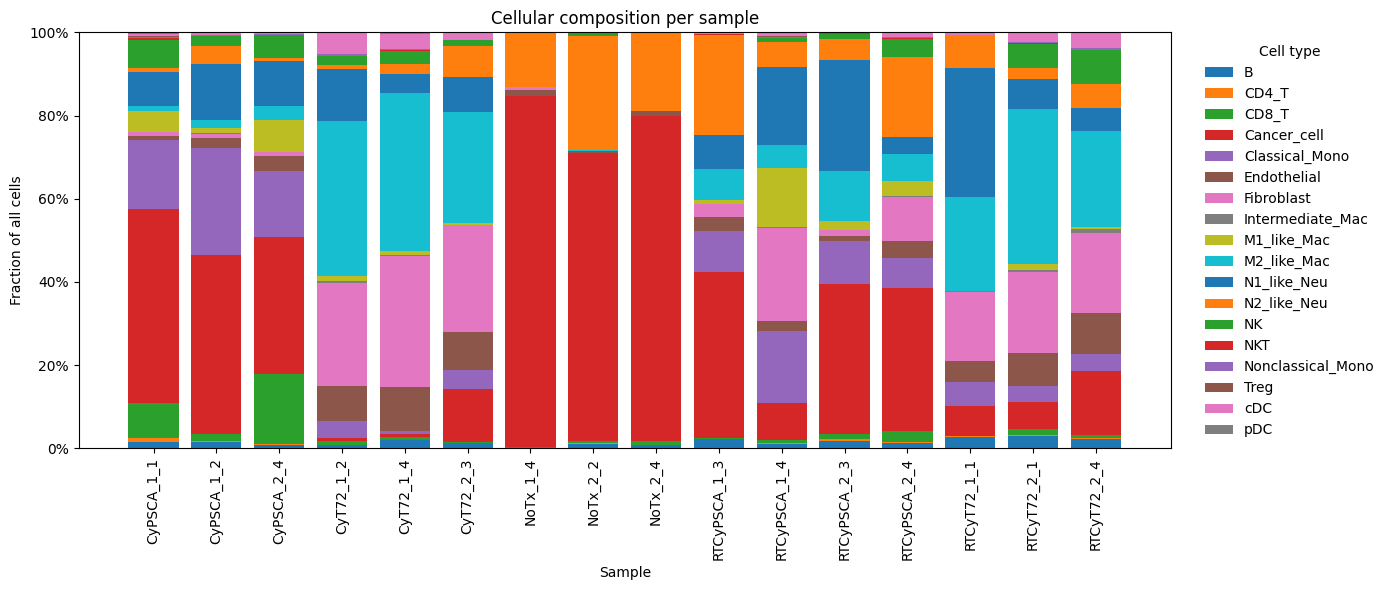

Summary:
Each bar is one tissue/sample. Fractions are normalized within sample, so all bars sum to 100%.


In [26]:
# Separate numeric cell-type columns from metadata
cell_type_cols = sample_counts.columns.tolist()

# Optional: sort samples by condition, then sample name
plot_df = sample_fractions.copy()
plot_df = plot_df.sort_values([condition_col, sample_col])

plot_cell_frac = plot_df[cell_type_cols]

fig, ax = plt.subplots(figsize=(14, 6))

bottom = np.zeros(plot_cell_frac.shape[0])

for ct in cell_type_cols:
    ax.bar(
        plot_cell_frac.index,
        plot_cell_frac[ct],
        bottom=bottom,
        label=ct
    )
    bottom += plot_cell_frac[ct].values

ax.set_ylabel("Fraction of all cells")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Sample")
ax.set_title("Cellular composition per sample")
ax.tick_params(axis="x", rotation=90)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    title="Cell type"
)

plt.tight_layout()
plt.show()

print("Summary:")
print("Each bar is one tissue/sample. Fractions are normalized within sample, so all bars sum to 100%.")

Major cell types:
['Cancer_cell', 'N2_like_Neu', 'M2_like_Mac', 'Fibroblast', 'Classical_Mono', 'N1_like_Neu', 'Endothelial', 'NK', 'CD8_T', 'M1_like_Mac', 'B']

Collapsed into Other:
['cDC', 'CD4_T', 'Intermediate_Mac', 'Nonclassical_Mono', 'pDC', 'NKT', 'Treg']


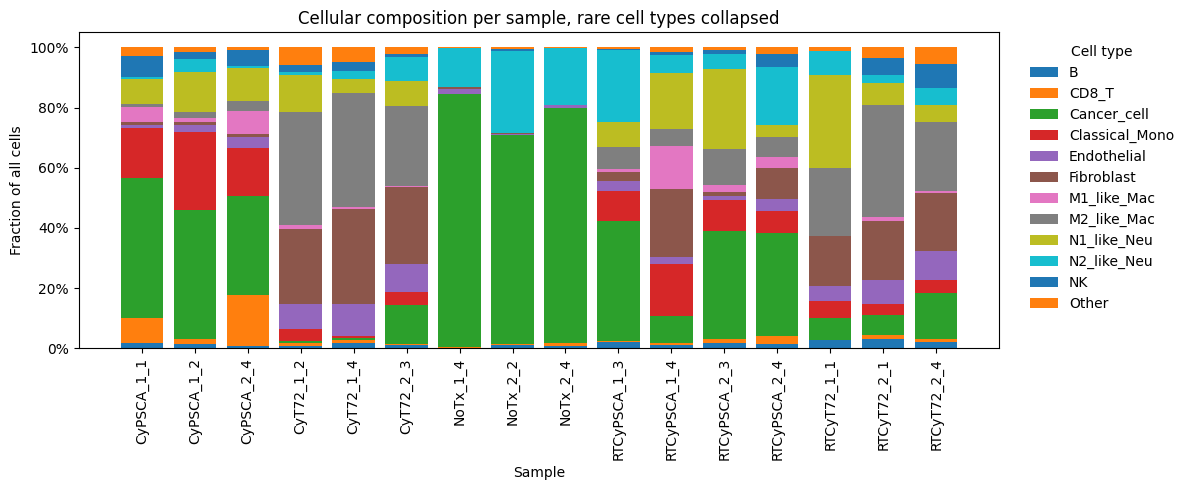

Summary:
Cell types below 1% global abundance were collapsed into Other.


In [27]:
# Define rare cell types based on global abundance
# Rare cell types lumped to 1%
min_global_fraction = 0.01  # 1%

global_fraction = obs[cell_col].value_counts(normalize=True)
major_cell_types = global_fraction[global_fraction >= min_global_fraction].index.tolist()
rare_cell_types = global_fraction[global_fraction < min_global_fraction].index.tolist()

print("Major cell types:")
print(major_cell_types)

print("\nCollapsed into Other:")
print(rare_cell_types)

obs_collapsed = obs.copy()
obs_collapsed["cell_type_collapsed"] = np.where(
    obs_collapsed[cell_col].isin(major_cell_types),
    obs_collapsed[cell_col],
    "Other"
)

collapsed_counts = pd.crosstab(obs_collapsed[sample_col], obs_collapsed["cell_type_collapsed"])
collapsed_fractions = collapsed_counts.div(collapsed_counts.sum(axis=1), axis=0)

collapsed_fractions = collapsed_fractions.join(sample_metadata)
collapsed_fractions = collapsed_fractions.sort_values([condition_col, sample_col])

collapsed_cell_cols = collapsed_counts.columns.tolist()
plot_df = collapsed_fractions[collapsed_cell_cols]

fig, ax = plt.subplots(figsize=(12, 5))

bottom = np.zeros(plot_df.shape[0])

for ct in collapsed_cell_cols:
    ax.bar(
        plot_df.index,
        plot_df[ct],
        bottom=bottom,
        label=ct
    )
    bottom += plot_df[ct].values

ax.set_ylabel("Fraction of all cells")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Sample")
ax.set_title("Cellular composition per sample, rare cell types collapsed")
ax.tick_params(axis="x", rotation=90)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    title="Cell type"
)

plt.tight_layout()
plt.show()

print("Summary:")
print(f"Cell types below {min_global_fraction:.0%} global abundance were collapsed into Other.")

# Lineage-level composition

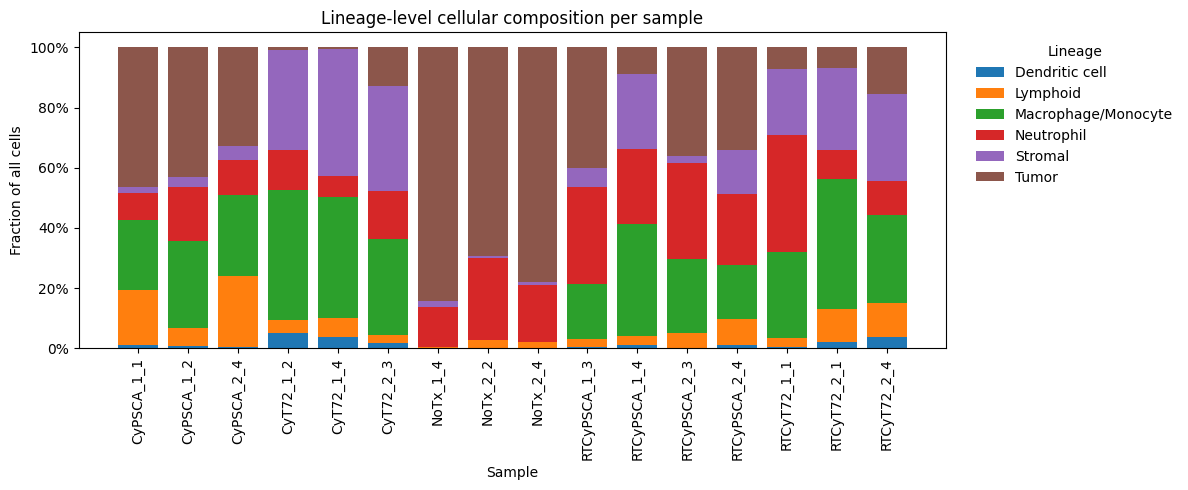

Summary:
This plot collapses detailed cell annotations into broader biological compartments.


In [28]:
lineage_map = {
    "Cancer_cell": "Tumor",

    "N1_like_Neu": "Neutrophil",
    "N2_like_Neu": "Neutrophil",

    "M1_like_Mac": "Macrophage/Monocyte",
    "M2_like_Mac": "Macrophage/Monocyte",
    "Intermediate_Mac": "Macrophage/Monocyte",
    "Classical_Mono": "Macrophage/Monocyte",
    "Nonclassical_Mono": "Macrophage/Monocyte",

    "CD8_T": "Lymphoid",
    "CD4_T": "Lymphoid",
    "Treg": "Lymphoid",
    "NK": "Lymphoid",
    "NKT": "Lymphoid",
    "B": "Lymphoid",

    "cDC": "Dendritic cell",
    "pDC": "Dendritic cell",

    "Fibroblast": "Stromal",
    "Endothelial": "Stromal",

    "Erythrocyte": "Erythrocyte"
}

obs_lineage = obs.copy()
obs_lineage["lineage"] = obs_lineage[cell_col].map(lineage_map).fillna("Other")

lineage_counts = pd.crosstab(obs_lineage[sample_col], obs_lineage["lineage"])
lineage_fractions = lineage_counts.div(lineage_counts.sum(axis=1), axis=0)

lineage_fractions = lineage_fractions.join(sample_metadata)
lineage_fractions = lineage_fractions.sort_values([condition_col, sample_col])

lineage_cols = lineage_counts.columns.tolist()
plot_df = lineage_fractions[lineage_cols]

fig, ax = plt.subplots(figsize=(12, 5))

bottom = np.zeros(plot_df.shape[0])

for lineage in lineage_cols:
    ax.bar(
        plot_df.index,
        plot_df[lineage],
        bottom=bottom,
        label=lineage
    )
    bottom += plot_df[lineage].values

ax.set_ylabel("Fraction of all cells")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Sample")
ax.set_title("Lineage-level cellular composition per sample")
ax.tick_params(axis="x", rotation=90)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    title="Lineage"
)

plt.tight_layout()
plt.show()

print("Summary:")
print("This plot collapses detailed cell annotations into broader biological compartments.")

B                         CD4_T                      \
                   mean       std       sem      mean       std       sem   
treatment                                                                   
CyPSCA_Tu1     0.015445  0.001171  0.000828  0.006608  0.003979  0.002814   
CyPSCA_Tu2     0.008829       NaN       NaN  0.001188       NaN       NaN   
CyTAG72_Tu1    0.014070  0.007519  0.005317  0.000494  0.000108  0.000077   
CyTAG72_Tu2    0.012287       NaN       NaN  0.000326       NaN       NaN   
NoTx_Tu1       0.000573       NaN       NaN  0.000164       NaN       NaN   
NoTx_Tu2       0.009167  0.002038  0.001441  0.001574  0.000357  0.000253   
RTCyPSCA_Tu1   0.016282  0.007591  0.005368  0.000994  0.000088  0.000062   
RTCyPSCA_Tu2   0.016135  0.003028  0.002141  0.003241  0.001244  0.000880   
RTCyTAG72_Tu1  0.026258       NaN       NaN  0.003282       NaN       NaN   
RTCyTAG72_Tu2  0.026188  0.005411  0.003826  0.001930  0.000376  0.000266   

                  CD8_T                     Cancer_cell  ...  \
                   mean       std       sem        mean  ...   
treatment                                                ...   
CyPSCA_Tu1     0.049613  0.047440  0.033545    0.447563  ...   
CyPSCA_Tu2     0.169270       NaN       NaN    0.328693  ...   
CyTAG72_Tu1    0.008368  0.000545  0.000385    0.007310  ...   
CyTAG72_Tu2    0.002610       NaN       NaN    0.128629  ...   
NoTx_Tu1       0.003273       NaN       NaN    0.842484  ...   
NoTx_Tu2       0.007400  0.003408  0.002410    0.736895  ...   
RTCyPSCA_Tu1   0.005246  0.003499  0.002474    0.244393  ...   
RTCyPSCA_Tu2   0.019392  0.009433  0.006670    0.351231  ...   
RTCyTAG72_Tu1  0.000000       NaN       NaN    0.073304  ...   
RTCyTAG72_Tu2  0.010344  0.004394  0.003107    0.110375  ...   

              Nonclassical_Mono      Treg                           cDC  \
                            sem      mean       std       sem      mean   
treatment                                                                 
CyPSCA_Tu1             0.000326  0.001247  0.000659  0.000466  0.005770   
CyPSCA_Tu2                  NaN  0.000000       NaN       NaN  0.005093   
CyTAG72_Tu1            0.000099  0.001333  0.000473  0.000335  0.042895   
CyTAG72_Tu2                 NaN  0.000217       NaN       NaN  0.017506   
NoTx_Tu1                    NaN  0.000000       NaN       NaN  0.000900   
NoTx_Tu2               0.000000  0.000000  0.000000  0.000000  0.000475   
RTCyPSCA_Tu1           0.000933  0.000599  0.000847  0.000599  0.006902   
RTCyPSCA_Tu2           0.000779  0.000883  0.000235  0.000166  0.005977   
RTCyTAG72_Tu1               NaN  0.000000       NaN       NaN  0.004376   
RTCyTAG72_Tu2          0.001145  0.000920  0.000381  0.000269  0.027478   

                                        pDC                      
                    std       sem      mean       std       sem  
treatment                                                        
CyPSCA_Tu1     0.000428  0.000303  0.002104  0.001870  0.001322  
CyPSCA_Tu2          NaN       NaN  0.000000       NaN       NaN  
CyTAG72_Tu1    0.010667  0.007542  0.002413  0.002233  0.001579  
CyTAG72_Tu2         NaN       NaN  0.000000       NaN       NaN  
NoTx_Tu1            NaN       NaN  0.000000       NaN       NaN  
NoTx_Tu2       0.000600  0.000425  0.000107  0.000080  0.000056  
RTCyPSCA_Tu1   0.003227  0.002282  0.000332  0.000283  0.000200  
RTCyPSCA_Tu2   0.004905  0.003469  0.000746  0.000801  0.000566  
RTCyTAG72_Tu1       NaN       NaN  0.001094       NaN       NaN  
RTCyTAG72_Tu2  0.010778  0.007621  0.002466  0.000007  0.000005  

[10 rows x 54 columns]

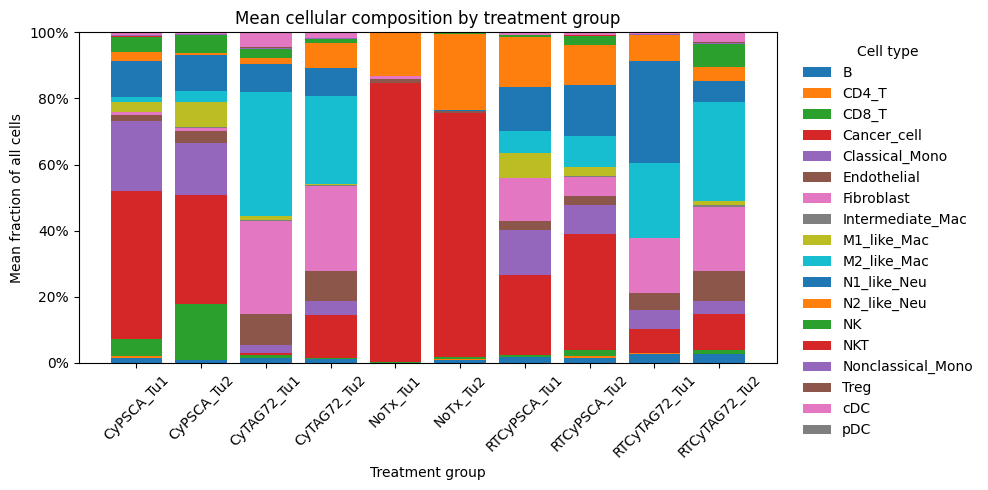

Summary:
Treatment-group bars are calculated from per-sample fractions, not pooled cells.


In [ ]:
# Statistical measure per group condition

condition_summary = (
    sample_fractions
    .groupby(condition_col)[cell_type_cols]
    .agg(["mean", "std", "sem"])
)

display(condition_summary)

condition_mean = sample_fractions.groupby(condition_col)[cell_type_cols].mean()

fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(condition_mean.shape[0])

for ct in cell_type_cols:
    ax.bar(
        condition_mean.index,
        condition_mean[ct],
        bottom=bottom,
        label=ct
    )
    bottom += condition_mean[ct].values

ax.set_ylabel("Mean fraction of all cells")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Treatment group")
ax.set_title("Mean cellular composition by treatment group")
ax.tick_params(axis="x", rotation=45)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    title="Cell type"
)

plt.tight_layout()
plt.show()

print("Summary:")
print("Treatment-group bars are calculated from per-sample fractions, not pooled cells.")

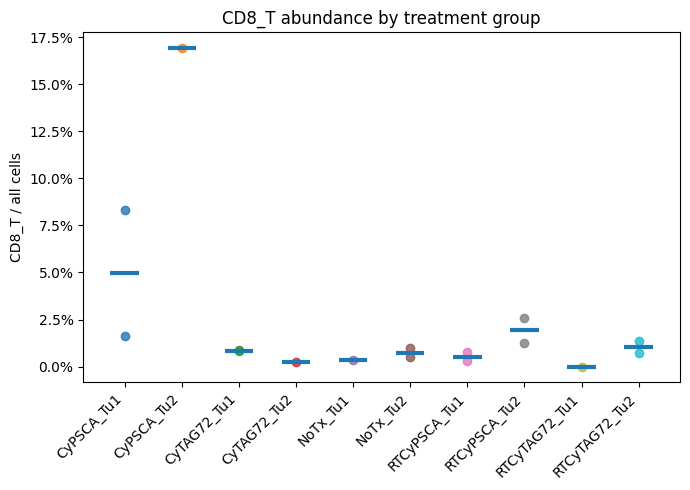

Summary:
This plot shows CD8_T as a fraction of all segmented cells in each sample.


In [36]:
cell_of_interest = "CD8_T"

focus_df = sample_fractions[[cell_of_interest, condition_col]].copy()
focus_df = focus_df.rename(columns={cell_of_interest: "fraction"})
focus_df = focus_df.sort_values(condition_col)

fig, ax = plt.subplots(figsize=(7, 5))

conditions = focus_df[condition_col].unique()
x_positions = np.arange(len(conditions))

for i, cond in enumerate(conditions):
    y = focus_df.loc[focus_df[condition_col] == cond, "fraction"]

    # sample dots
    ax.scatter(
        np.repeat(i, len(y)),
        y,
        alpha=0.8
    )

    # condition mean
    ax.hlines(
        y.mean(),
        i - 0.25,
        i + 0.25,
        linewidth=3
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(conditions, rotation=45, ha="right")
ax.set_ylabel(f"{cell_of_interest} / all cells")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title(f"{cell_of_interest} abundance by treatment group")

plt.tight_layout()
plt.show()

print("Summary:")
print(f"This plot shows {cell_of_interest} as a fraction of all segmented cells in each sample.")

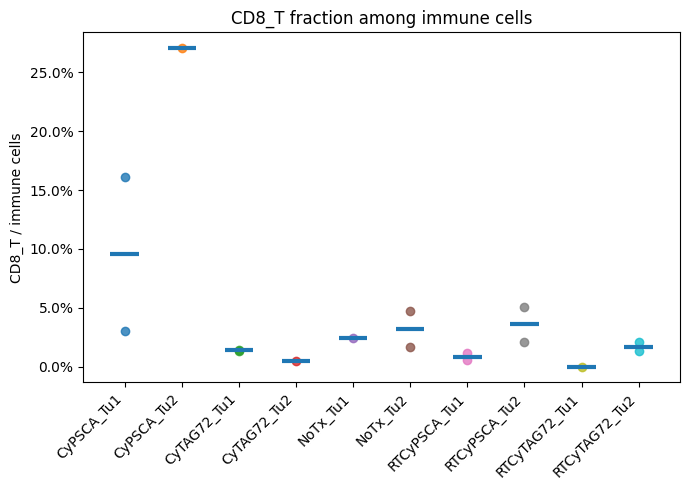

Summary:
This plot shows CD8_T as a fraction of immune cells only.


In [34]:
immune_cell_types = [
    "N2_like_Neu",
    "M2_like_Mac",
    "Classical_Mono",
    "N1_like_Neu",
    "NK",
    "CD8_T",
    "M1_like_Mac",
    "B",
    "cDC",
    "CD4_T",
    "Intermediate_Mac",
    "Nonclassical_Mono",
    "pDC",
    "NKT",
    "Treg"
]

cell_of_interest = "CD8_T"

immune_obs = obs[obs[cell_col].isin(immune_cell_types)].copy()

immune_counts = pd.crosstab(immune_obs[sample_col], immune_obs[cell_col])
immune_fractions = immune_counts.div(immune_counts.sum(axis=1), axis=0)

immune_fractions = immune_fractions.join(sample_metadata)

focus_df = immune_fractions[[cell_of_interest, condition_col]].copy()
focus_df = focus_df.rename(columns={cell_of_interest: "fraction"})
focus_df = focus_df.dropna()
focus_df = focus_df.sort_values(condition_col)

fig, ax = plt.subplots(figsize=(7, 5))

conditions = focus_df[condition_col].unique()
x_positions = np.arange(len(conditions))

for i, cond in enumerate(conditions):
    y = focus_df.loc[focus_df[condition_col] == cond, "fraction"]

    ax.scatter(
        np.repeat(i, len(y)),
        y,
        alpha=0.8
    )

    ax.hlines(
        y.mean(),
        i - 0.25,
        i + 0.25,
        linewidth=3
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(conditions, rotation=45, ha="right")
ax.set_ylabel(f"{cell_of_interest} / immune cells")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title(f"{cell_of_interest} fraction among immune cells")

plt.tight_layout()
plt.show()

print("Summary:")
print(f"This plot shows {cell_of_interest} as a fraction of immune cells only.")